In [41]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [2]:
os.chdir("/Users/kaiping/Desktop/olist_project/data") 
os.getcwd()

'/Users/kaiping/Desktop/olist_project/data'

In [3]:
df_translation = pd.read_csv("raw/product_category_name_translation.csv")
df_sellers     = pd.read_csv("raw/olist_sellers_dataset.csv")
df_products    = pd.read_csv("raw/olist_products_dataset.csv")
df_orders      = pd.read_csv("raw/olist_orders_dataset.csv")
df_order_reviews  = pd.read_csv("raw/olist_order_reviews_dataset.csv")
df_order_payments = pd.read_csv("raw/olist_order_payments_dataset.csv")
df_order_items    = pd.read_csv("raw/olist_order_items_dataset.csv")
df_geolocation    = pd.read_csv("raw/olist_geolocation_dataset.csv")
df_customers      = pd.read_csv("raw/olist_customers_dataset.csv")


In [4]:
tables = {
    "translation": df_translation,
    "sellers": df_sellers,
    "products": df_products,
    "orders": df_orders,
    "order_reviews": df_order_reviews,
    "order_payments": df_order_payments,
    "order_items": df_order_items,
    "geolocation": df_geolocation,
    "customers": df_customers
}


### 1. 篩選orders_delivered_base


In [5]:
# 0. order_status 比例分析
(df_orders["order_status"]
 .value_counts(normalize=True)
 .mul(100)
 .round(1)
)


order_status
delivered      97.0
shipped         1.1
canceled        0.6
unavailable     0.6
invoiced        0.3
processing      0.3
created         0.0
approved        0.0
Name: proportion, dtype: float64

In [6]:
# 1. customer 表只取需要欄位，避免 join 太多沒必要欄位

customer_map = df_customers[["customer_id", "customer_unique_id"]].copy() 

# 2. orders 表先篩選 delivered

orders_delivered = df_orders.loc[
    df_orders["order_status"].eq("delivered"),
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

# 3. join customer 表，補上 customer_unique_id
orders_delivered_base = orders_delivered.merge(
    customer_map,
    on="customer_id",
    how="left",
    validate="many_to_one"   # 多筆 orders 對一筆 customer
)

# 4. 欄位順序整理
orders_delivered_base = orders_delivered_base[
    [
        "order_id",
        "customer_id",
        "customer_unique_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

# 5. 時間欄位轉 datetime
datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in datetime_cols:
    orders_delivered_base[col] = pd.to_datetime(
        orders_delivered_base[col],
        errors="coerce"
    )

In [7]:
# 檢查結果
print(orders_delivered_base.shape)


(96478, 9)


In [8]:
orders_delivered_base.head()


,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26


In [9]:
print(orders_delivered_base.isna().sum())

order_id                          0
customer_id                       0
customer_unique_id                0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64


In [10]:
# 檢查 order_id 是否仍唯一
print("order_id duplicated:", orders_delivered_base["order_id"].duplicated().sum())

order_id duplicated: 0


In [11]:
os.chdir("/Users/kaiping/Desktop/olist_project/data/interim")

orders_delivered_base_output_path = Path("orders_delivered_base.csv")

if not orders_delivered_base_output_path.exists():
    orders_delivered_base.to_csv(orders_delivered_base_output_path, index=False, encoding="utf-8-sig")
    print(f"已儲存：{orders_delivered_base_output_path}（位於 {os.getcwd()}）")
else:
    print(f"已存在，未覆蓋：{orders_delivered_base_output_path}（位於 {os.getcwd()}）")

已存在，未覆蓋：orders_delivered_base.csv（位於 /Users/kaiping/Desktop/olist_project/data/interim）


### 2. 資料時間覆蓋確認

In [12]:
delivered_rows = len(orders_delivered_base)
min_purchase_ts = orders_delivered_base["order_purchase_timestamp"].min()
max_purchase_ts = orders_delivered_base["order_purchase_timestamp"].max()

print("delivered rows:", delivered_rows)
print("min order_purchase_timestamp:", min_purchase_ts)
print("max order_purchase_timestamp:", max_purchase_ts)

delivered rows: 96478
min order_purchase_timestamp: 2016-09-15 12:16:00
max order_purchase_timestamp: 2018-08-29 15:00:00


### 3. 每月訂單趨勢

In [14]:
# 建立月份欄位
orders_delivered_base["purchase_month"] = (
    orders_delivered_base["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)
# 每月訂單數量表
monthly_orders = (
    orders_delivered_base
    .groupby("purchase_month", as_index=False)
    .agg(monthly_orders=("order_id", "count"))
    .sort_values("purchase_month")
    .reset_index(drop=True)
)
monthly_orders

,purchase_month,monthly_orders
0,2016-09-01,1
1,2016-10-01,265
2,2016-12-01,1
3,2017-01-01,750
4,2017-02-01,1653
5,2017-03-01,2546
6,2017-04-01,2303
7,2017-05-01,3546
8,2017-06-01,3135
9,2017-07-01,3872


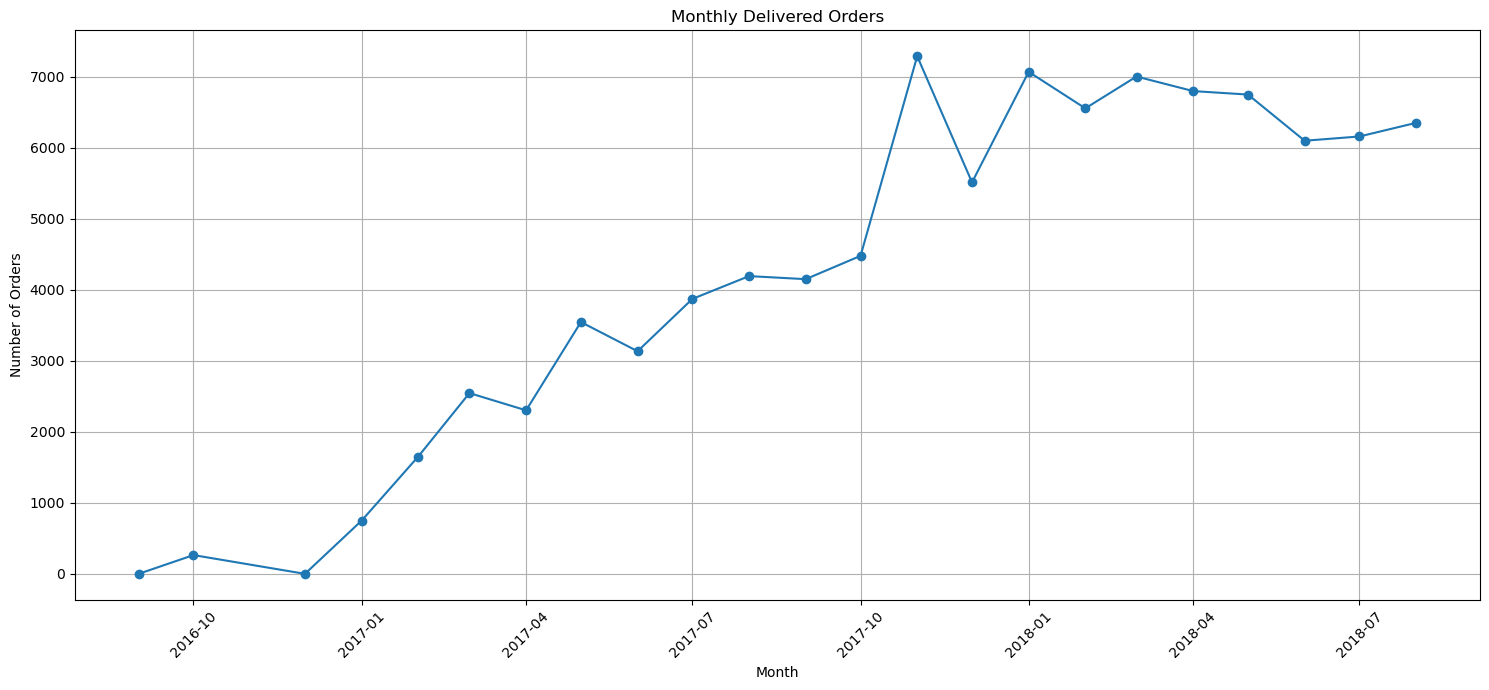

In [15]:
plt.figure(figsize=(15, 7))
plt.plot(monthly_orders["purchase_month"], monthly_orders["monthly_orders"], marker="o")
plt.title("Monthly Delivered Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


### 4. 每週訂單數趨勢

In [47]:
# 建立週別欄位
orders_delivered_base["purchase_week"] = (
    orders_delivered_base["order_purchase_timestamp"]
    .dt.to_period("W-MON")
    .dt.start_time
)

# 每週訂單數量
weekly_orders = (
    orders_delivered_base
    .groupby("purchase_week", as_index=False)
    .agg(
        weekly_orders=("order_id", "count")
    )
    .sort_values("purchase_week")
    .reset_index(drop=True)
)

weekly_orders.head()

,purchase_week,weekly_orders
0,2016-09-13,1
1,2016-09-27,7
2,2016-10-04,258
3,2016-12-20,1
4,2017-01-03,49


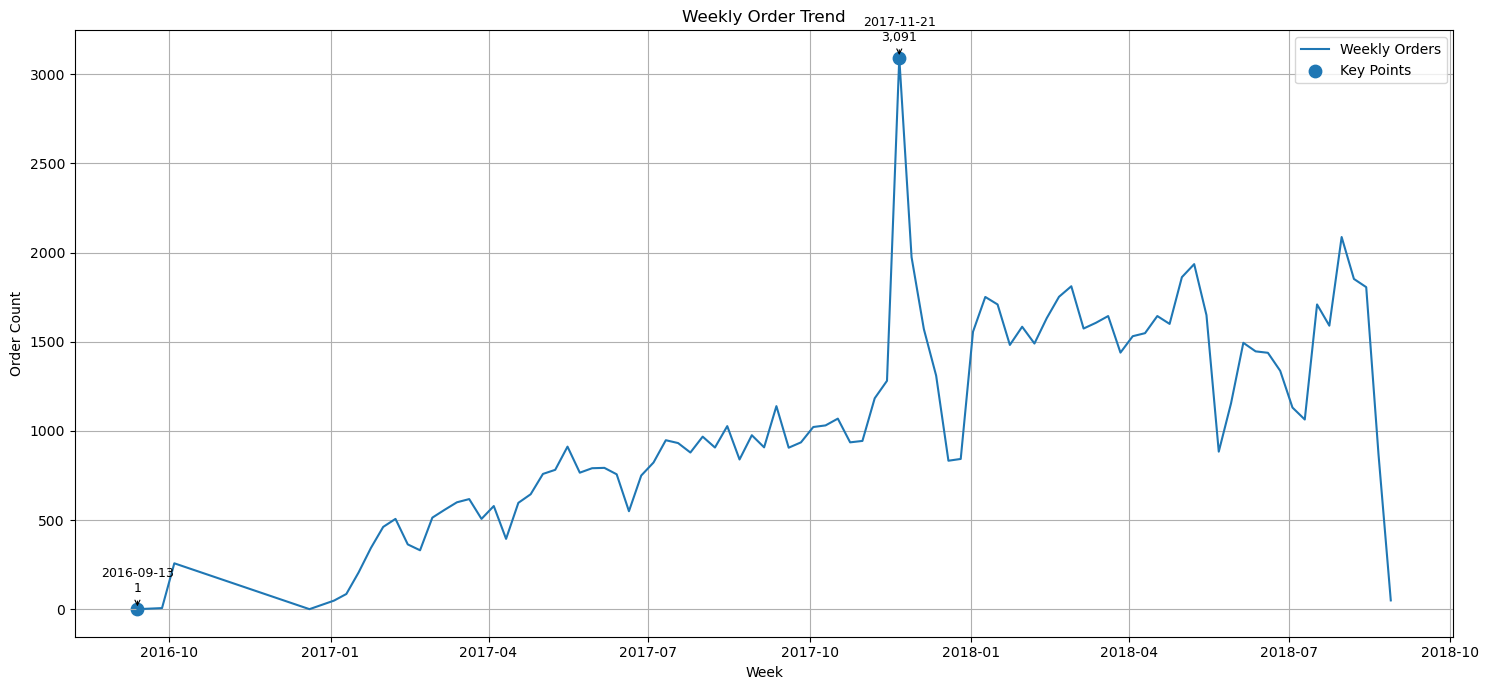

In [53]:
# 找最高週與最低週
max_week = weekly_orders.loc[weekly_orders["weekly_orders"].idxmax()]
min_week = weekly_orders.loc[weekly_orders["weekly_orders"].idxmin()]

key_points = pd.DataFrame([max_week, min_week])

plt.figure(figsize=(15,7))

plt.plot(
    weekly_orders["purchase_week"],
    weekly_orders["weekly_orders"],
    label="Weekly Orders"
)

plt.scatter(
    key_points["purchase_week"],
    key_points["weekly_orders"],
    s=80,
    label="Key Points"
)

for _, row in key_points.iterrows():
    plt.annotate(
        f'{row["purchase_week"].strftime("%Y-%m-%d")}\n{row["weekly_orders"]:,}',
        xy=(row["purchase_week"], row["weekly_orders"]),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        arrowprops=dict(
            arrowstyle="->",
            linewidth=0.8
        )
    )

plt.title("Weekly Order Trend")
plt.xlabel("Week")
plt.ylabel("Order Count")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 5. GMV分佈

In [17]:
# 每筆訂單的商品金額總和
order_gmv = (
    df_order_items
    .groupby("order_id", as_index=False)
    .agg(
        order_gmv=("price", "sum")
    )
)

# 匯總回訂單表
orders_delivered_base = orders_delivered_base.merge(
    order_gmv,
    on="order_id",
    how="left",
    validate="one_to_one"
)

In [18]:
orders_delivered_base.isna().sum()

order_id                          0
customer_id                       0
customer_unique_id                0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
purchase_month                    0
order_gmv                         0
dtype: int64

In [19]:
# 顧客(customer_unique_id) GMV分佈
customer_gmv = (
    orders_delivered_base
    .groupby("customer_unique_id", as_index=False)
    .agg(
        total_gmv=("order_gmv", "sum")
    )
)

customer_gmv.head()

,customer_unique_id,total_gmv
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90
2,0000f46a3911fa3c0805444483337064,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,25.99
4,0004aac84e0df4da2b147fca70cf8255,180.00


In [39]:
print("GMV最小值",customer_gmv["total_gmv"].min())
print("GMV最大值",customer_gmv["total_gmv"].max())

GMV最小值 0.85
GMV最大值 13440.0


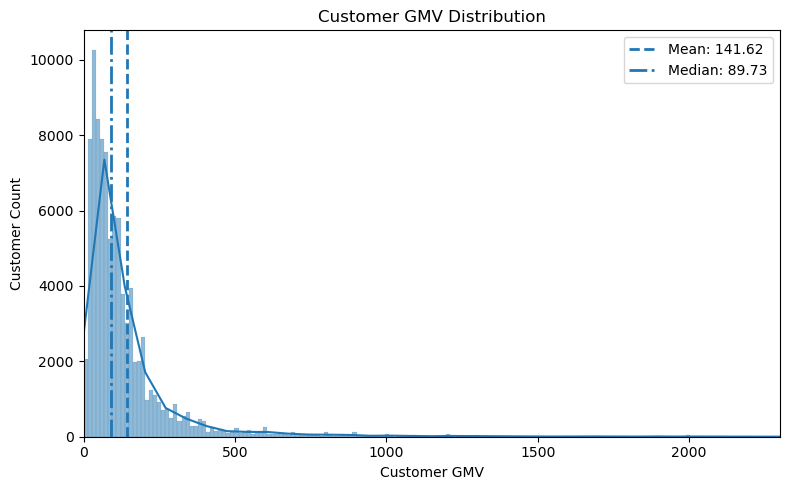

In [46]:
# 計算統計量
mean_gmv = customer_gmv["total_gmv"].mean()
median_gmv = customer_gmv["total_gmv"].median()

plt.figure(figsize=(8,5))

sns.histplot(
    customer_gmv["total_gmv"],
    bins=1000,
    kde=True
)

# Mean
plt.axvline(
    mean_gmv,
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_gmv:.2f}"
)

# Median
plt.axvline(
    median_gmv,
    linestyle="-.",
    linewidth=2,
    label=f"Median: {median_gmv:.2f}"
)

plt.xlabel("Customer GMV")
plt.ylabel("Customer Count")
plt.title("Customer GMV Distribution")

plt.xlim(
    0,
    customer_gmv["total_gmv"].quantile(0.999) 
) # 忽略極端值

# 顯示圖例
plt.legend()

plt.tight_layout()
plt.show()

###  6. 右截尾分析

In [52]:
N = 90

# 1. 資料截止日
data_end = orders_delivered_base["order_purchase_timestamp"].max()

# 2. 分析截止日 = data_end - 90天
analysis_end = data_end - pd.Timedelta(days=N)

# 3. 找出右截尾風險訂單
right_censored_orders = orders_delivered_base[
    orders_delivered_base["order_purchase_timestamp"] > analysis_end
].copy()

# 4. 右截尾風險訂單數
risk_customers = right_censored_orders["customer_unique_id"].nunique()

# 5. 全部顧訂單數
total_customers = orders_delivered_base["customer_unique_id"].nunique()

# 6. 風險顧訂單比
risk_ratio = risk_customers / total_customers

# 7. 輸出
print(f"data_end: {data_end}")
print(f"analysis_end (data_end - N): {analysis_end}")
print(f"右截尾風險顧客數量佔比: {risk_customers} / {total_customers} ({risk_ratio:.2%})")

data_end: 2018-08-29 15:00:00
analysis_end (data_end - N): 2018-05-31 15:00:00
右截尾風險顧客數量佔比: 18459 / 93358 (19.77%)
